<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/NASSCOM_Day_2_P%26S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


## 2. Distributions & Relationships

### 2D. NUMERICAL vs NUMERICAL RELATIONSHIPS

In [10]:
# Mean of a numerical column (tip)
print(f'Mean tip: {df["tip"].mean():.2f}')

Mean tip: 3.00


In [11]:
# Value counts of a categorical column (sex)

print('Sex value counts:')
print(df['sex'].value_counts())

Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


In [12]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


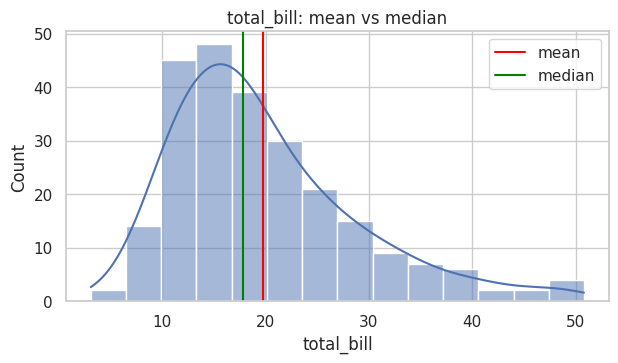

In [15]:
# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

### 2C. MEAN, MEDIAN, MODE for TIP

In [16]:
# mean, median, mode
ol_tip = df['tip']
print('Mean   :', round(col_tip.mean(), 2))
print('Median :', round(col_tip.median(), 2))
print('Mode   :', round(col_tip.mode()[0], 2))

Mean   : 3.0
Median : 2.9
Mode   : 2.0


Mean > Median? : Yes

mean > median ? True -> right-skewed


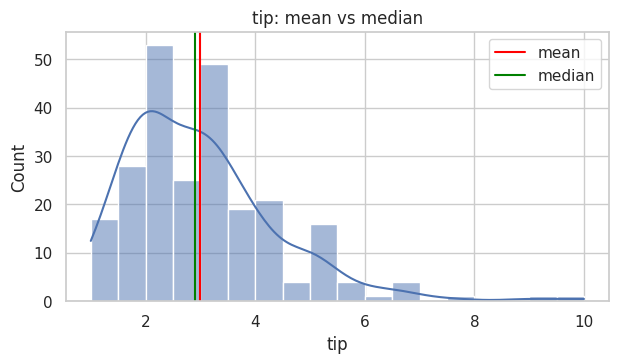

In [17]:
print('mean > median ?', col_tip.mean() > col_tip.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col_tip, kde=True)
plt.axvline(col_tip.mean(),   color='red',   label='mean')
plt.axvline(col_tip.median(), color='green', label='median')
plt.legend(); plt.title('tip: mean vs median'); plt.show()

In [18]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

Range : 47.74
Var   : 79.25
Std   : 8.9


In [19]:

# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [20]:
tip = df['tip']

In [22]:
# range, variance, std
col = df['tip']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

Range : 9.0
Var   : 1.91
Std   : 1.38


In [24]:
# Q1, Q3, IQR
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56 -> spread of the middle 50% (robust to outliers)


In [27]:
col = df['tip']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


The most robust measure of spread is the Interquartile Range (IQR).

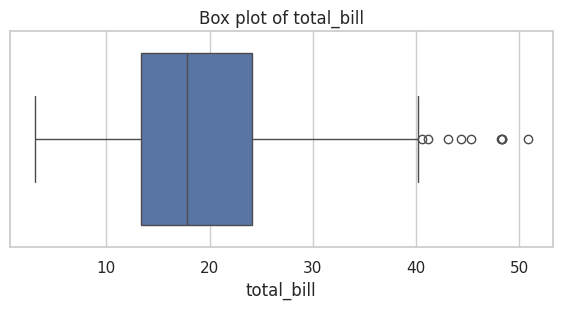

In [26]:
# -----------------------------------------------------------
# 🔹 4B. BOX PLOT (a picture of the five-number summary)
# -----------------------------------------------------------

# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

In [25]:
# -----------------------------------------------------------
# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
# -----------------------------------------------------------

col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


Here is the five-number summary for the 'tip' column:

Minimum (min): 1.00
First Quartile (Q1): 2.00
Median (50%): 2.90
Third Quartile (Q3): 3.56
Maximum (max): 10.00

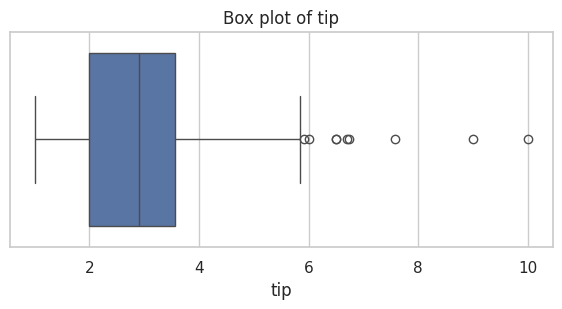

In [28]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['tip'])
plt.title('Box plot of tip'); plt.show()

In [29]:
# -----------------------------------------------------------
# 🔹 5A. CORRELATION between numerical columns
# -----------------------------------------------------------

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


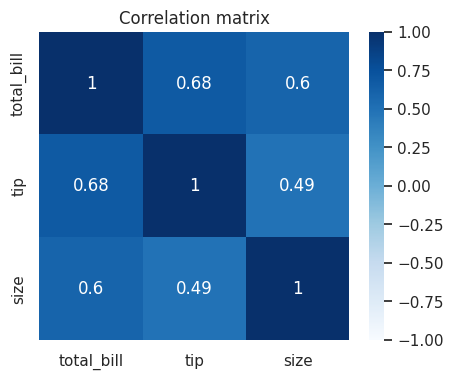

In [30]:
# -----------------------------------------------------------
# 🔹 5B. VISUALISE THE CORRELATION MATRIX
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [31]:

# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [35]:
display(df.describe())

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [33]:
# correlation matrix (rounded)

display(corr.round(2))

,total_bill,tip,size
total_bill,1.00,0.68,0.60
tip,0.68,1.00,0.49
size,0.60,0.49,1.00


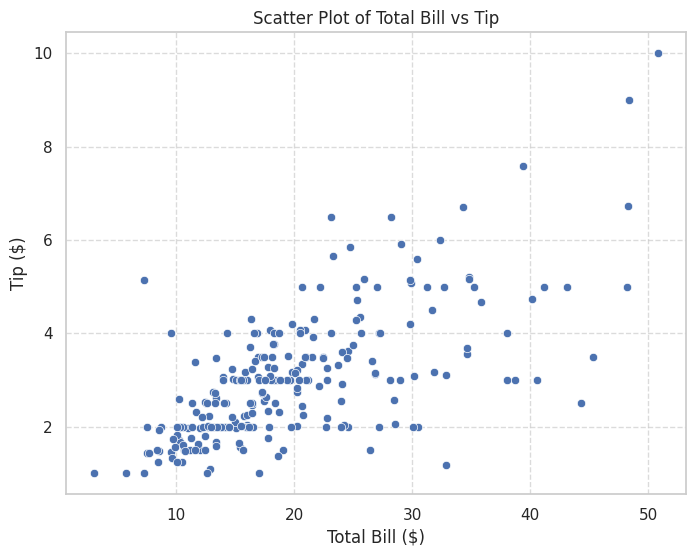

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title('Scatter Plot of Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Insights from `df.describe()`:

1.  **Tip Variability:** The `tip` column has a relatively low standard deviation (1.38) compared to its mean (3.00), suggesting that most tips are clustered around the average, with some higher tips as indicated by the maximum (10.00).
2.  **Bill Range:** The `total_bill` column shows a wide range, from a minimum of $3.07 to a maximum of $50.81, indicating a diverse customer base in terms of spending habits.
3.  **Party Size:** The `size` column indicates that most dining parties consist of 2 people (median and mode are both 2, implied by Q1 and Q3 ranging from 2-3), with a maximum party size of 6.